## WildGuardMix EDA


### Load Dependencies and Data

In [ ]:
# Dependencies

import pandas as pd
import matplotlib.pyplot as plt
from pyprojroot import here
from sklearn.model_selection import train_test_split


# Project path anchors
REPO_ROOT = here()
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = REPO_ROOT / "data" / "processed"
MODEL_DIR = REPO_ROOT / "data" / "models"


In [ ]:
# Load Data
train_file = RAW_DATA_DIR / "wildguardmix" / "train" / "wildguard_train.parquet"
test_file = RAW_DATA_DIR / "wildguardmix" / "test" / "wildguard_test.parquet"
final_file = PROCESSED_DATA_DIR / "wildguardmix_single_turn.parquet"

df_train = pd.read_parquet(train_file)
df_test = pd.read_parquet(test_file)

# Add source column
df_train["source_split"] = "train"
df_test["source_split"] = "test"

# Combine for EDA
combined = pd.concat([df_train, df_test], ignore_index=True)


### Review the overall data

In [ ]:
# View Overall Structure
combined.info()


<class 'pandas.DataFrame'>
RangeIndex: 88484 entries, 0 to 88483
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   prompt                      88484 non-null  str    
 1   adversarial                 88484 non-null  bool   
 2   response                    39659 non-null  str    
 3   prompt_harm_label           88458 non-null  str    
 4   response_refusal_label      39696 non-null  str    
 5   response_harm_label         39685 non-null  str    
 6   subcategory                 88484 non-null  str    
 7   source_split                88484 non-null  str    
 8   response_refusal_agreement  1720 non-null   float64
 9   prompt_harm_agreement       1699 non-null   float64
 10  response_harm_agreement     1709 non-null   float64
dtypes: bool(1), float64(3), str(7)
memory usage: 117.6 MB


In [ ]:
# Survey the prompt level category columns

label_columns = ['adversarial', 'prompt_harm_label', 'subcategory']

print(f"Training Data Columns: {label_columns}\n")

for col in label_columns:
    if col in combined.columns:
        
        unique_vals = combined[col].dropna().unique()
        num_categories = len(unique_vals)

        category_counts = combined[col].value_counts().to_dict()

        print(f"Column Name: {col}")
        print(f"  Total Categories: {num_categories}")
        print(f"  Type of Categories: {combined[col].dtype}")

        print(f"  Exact Categories and Numbers: {category_counts}")
        print("-" * 50)

Training Data Columns: ['adversarial', 'prompt_harm_label', 'subcategory']

Column Name: adversarial
  Total Categories: 2
  Type of Categories: bool
  Exact Categories and Numbers: {False: 46718, True: 41766}
--------------------------------------------------
Column Name: prompt_harm_label
  Total Categories: 2
  Type of Categories: str
  Exact Categories and Numbers: {'harmful': 46970, 'unharmful': 41488}
--------------------------------------------------
Column Name: subcategory
  Total Categories: 15
  Type of Categories: str
  Exact Categories and Numbers: {'benign': 41514, 'others': 10825, 'social_stereotypes_and_unfair_discrimination': 6419, 'disseminating_false_or_misleading_information_encouraging_disinformation_campaigns': 4128, 'sensitive_information_organization_government': 3135, 'toxic_language_hate_speech': 3061, 'violence_and_physical_harm': 2941, 'private_information_individual': 2616, 'defamation_encouraging_unethical_or_unsafe_actions': 2466, 'fraud_assisting_illegal

### Narrow the dataset to what we need

In [ ]:
# Focus the data into the columns that we will use to train the model: prompt, prompt-harm-label, adversarial, and subcategory
combined_col = combined[['prompt', 'prompt_harm_label', 'adversarial', 'subcategory', 'source_split']]

In [ ]:
# Quality preflight check
combined_col.info()


<class 'pandas.DataFrame'>
RangeIndex: 88484 entries, 0 to 88483
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   prompt             88484 non-null  str  
 1   prompt_harm_label  88458 non-null  str  
 2   adversarial        88484 non-null  bool 
 3   subcategory        88484 non-null  str  
 4   source_split       88484 non-null  str  
dtypes: bool(1), str(4)
memory usage: 47.8 MB


### Check Quality and Remove Non-essential Data

In [ ]:
# Create the final dataset
combined_final = combined_col.copy()

# Drop duplicate prompts
combined_final = combined_final.drop_duplicates(subset='prompt').reset_index(drop=True)

# Drop empty prompts
before = len(combined_final)
combined_final = combined_final[combined_final['prompt'].str.strip().astype(bool)].reset_index(drop=True)
print(f"Dropped {before - len(combined_final)} empty prompt(s) -> {len(combined_final):,} rows")


Dropped 1 empty prompt(s) -> 49,576 rows


In [ ]:
# Check to see what rows dont have data
combined_final.isna().sum()

In [ ]:
# Remove rows that don't have a prompt harm label (26 of them)
combined_final = combined_final[combined_final['prompt_harm_label'].notna()].copy()

### Review Distributions and Look for Imbalances

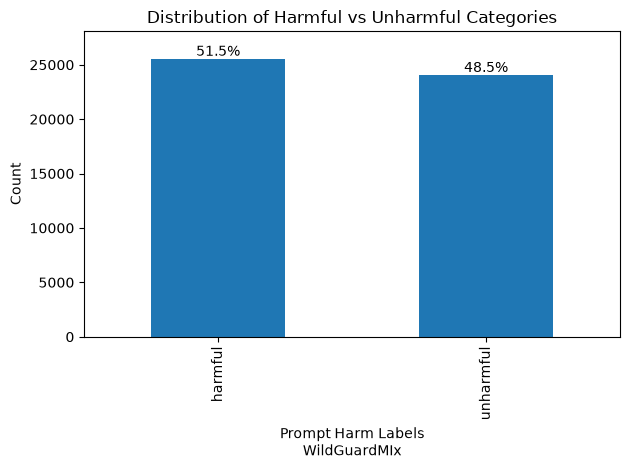

In [ ]:
# Calculate the distributions to show on the graph
counts = combined_final['prompt_harm_label'].value_counts()
pct = counts / counts.sum() * 100

# Show distribution of harmful vs unharmful
ax = counts.plot(kind="bar", title="Distribution of Harmful vs Unharmful Categories")
for i, (n, p) in enumerate(zip(counts, pct)):
    ax.text(i, n, f"{p:.1f}%", ha="center", va="bottom")
ax.set_ylabel("Count")
ax.set_xlabel("Prompt Harm Labels\nWildGuardMIx")
ax.margins(y=.1)
plt.tight_layout()
plt.show()

adversarial        False  True 
prompt_harm_label              
harmful             54.0   46.0
unharmful           50.2   49.8


<Axes: title={'center': 'adversarial vs vanilla, by harm class'}, xlabel='prompt_harm_label'>

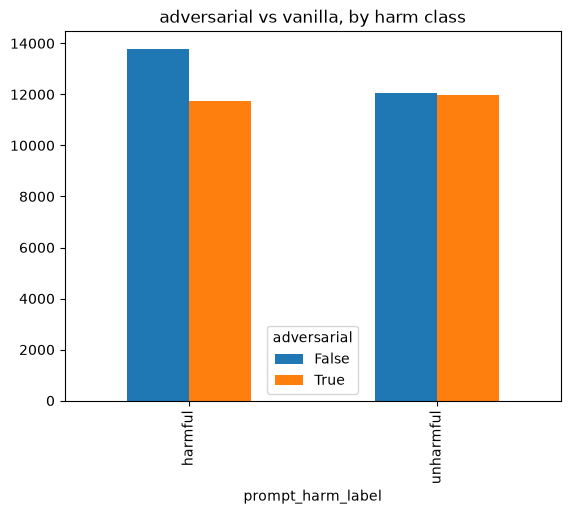

In [ ]:
# Determine whether or not adversarial phrases predict harm
print(pd.crosstab(combined_final['prompt_harm_label'], combined_final['adversarial'],
            normalize="index").mul(100).round(1))

# Show adversarial grouping by harm
ct = pd.crosstab(combined_final['prompt_harm_label'], combined_final['adversarial'])
ct.plot(kind="bar", title="adversarial vs vanilla, by harm class") 

In [ ]:
# Determine if the length is a potential signal
combined_final['prompt_length'] = combined_final['prompt'].str.split().str.len()

# Describe by class as a quick comparison
combined_final.groupby('prompt_harm_label')[['prompt_length']].describe()

prompt_length                                                \
                          count       mean        std  min   25%   50%    75%   
prompt_harm_label                                                               
harmful                 25521.0  86.963599  86.253354  1.0  17.0  44.0  136.0   
unharmful               24029.0  77.059595  89.278113  1.0  10.0  53.0  119.0   

                           
                      max  
prompt_harm_label          
harmful             773.0  
unharmful          1960.0

In [ ]:
# See how many of the prompts are unique
print(f"Total Number of Unique Prompts: {combined_final["prompt"].nunique()}")

Total Number of Unique Prompts: 49550


In [ ]:
# Create the train, test, validation split

train = combined_final[combined_final['source_split'] == 'train']
test = combined_final[combined_final['source_split'] == 'test']

train, val = train_test_split(train, test_size=.15, stratify=train['prompt_harm_label'], random_state=42)

print(f"train: {train.shape}   val: {val.shape}   test: {test.shape}")


train: (40673, 6)   val: (7178, 6)   test: (1699, 6)


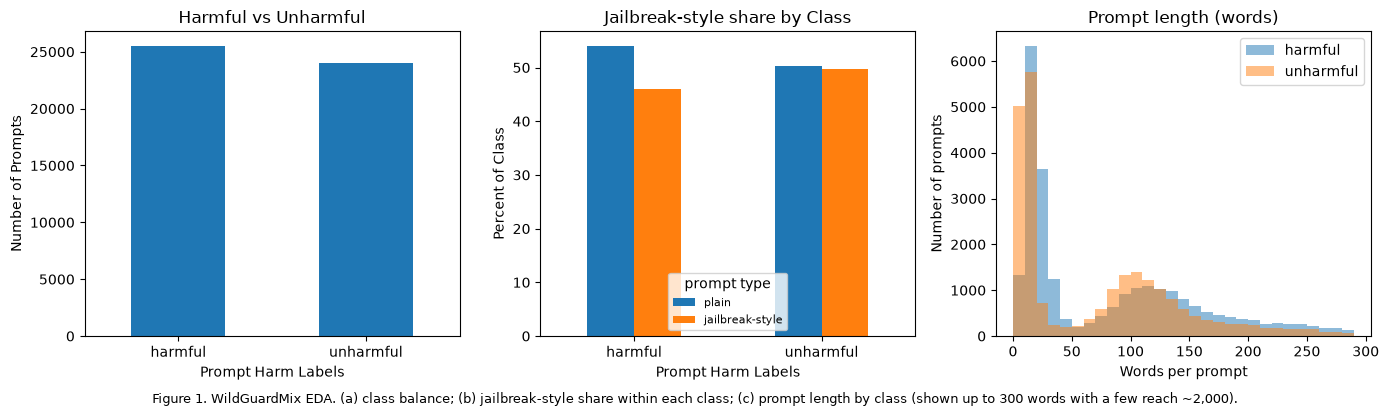

In [ ]:
# Consolidated figures for the milestone paper
fig, axes = plt.subplots(1, 3, figsize=(14,4))

# Figure 1a
combined_final['prompt_harm_label'].value_counts().plot(
    kind='bar', ax=axes[0], rot=0, label='(a) Harmful vs Unharmful')
axes[0].set_title("Harmful vs Unharmful")
axes[0].set_ylabel('Number of Prompts')
axes[0].set_xlabel('Prompt Harm Labels')

# Figure 1b
pd.crosstab(combined_final['prompt_harm_label'], combined_final['adversarial'],
            normalize="index").mul(100).plot(
                kind='bar', ax=axes[1], rot=0, label='(b) Jailbreak-style share by Class')
axes[1].set_title("Jailbreak-style share by Class")
axes[1].set_ylabel('Percent of Class')
axes[1].set_xlabel('Prompt Harm Labels')
axes[1].legend(["plain", "jailbreak-style"], title="prompt type",
               loc="lower center", fontsize=8)

# Figure 1c
combined_final['prompt_length'] = combined_final['prompt'].str.split().str.len()
for label, grp in combined_final.groupby('prompt_harm_label'):
    axes[2].hist(grp['prompt_length'], bins=range(0, 300, 10), alpha=0.5, label=label)
axes[2].set_title("Prompt length (words)")
axes[2].set_xlabel("Words per prompt")
axes[2].set_ylabel("Number of prompts")
axes[2].legend()

fig.text(0.5, -0.02,
         "Figure 1. WildGuardMix EDA. (a) class balance; "
         "(b) jailbreak-style share within each class; "
         "(c) prompt length by class (shown up to 300 words with a few reach ~2,000).",
         ha="center", fontsize=9, wrap=True)

plt.tight_layout()
plt.show()


In [ ]:
# Save final process file to the processed folder
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
combined_final.drop(columns='prompt_length').to_parquet(final_file, index=False)


### Takeaways and integration into the final schema



The final dataset has 49,550 unique single-turn prompts.

Schema:
- prompt: user prompt screen (string) input
- prompt_harm_label: harmful or unharmful (target)
- adversarial: adversarial/vanilla human assessment of jailbreak style phrasing (metadata)
- subcategory: harm subcategory (metadata)
- source_split: train or test from original dataset

Cleaning Decisions
- Kept prompt only rows.  
- Deduplicated to one row per unique prompt.
- Dropped 26 rows with no prompt harm label.

Findings:
- class balance is 51.5/48.5; nearly balanced
- adversarial style is roughly even across harm labels so jailbreak style is a low risk of becoming a harm shortcut.
- prompt length differs modestly by class but shouldn't be a real risk in length becoming a harm shortcut